# 3. Exploratory Data Analysis and Diagnostics

Every figure here is built from the cached event table alone — no model is fitted, so this
stage runs in seconds and can be iterated freely.

Three of these figures are not decoration; they are the evidence for open findings in the
methodology audit that had previously been asserted only in prose:

- the **correlation heatmap** and **VIF panel** are the evidence for P2-3, *"collinearity
  is severe and largely unaddressed"*;
- the **Y1↔Y3 dependence plot** makes the `Y3 = 0 ⟺ Y1 ≥ 0` identity (P1-3) visible rather
  than merely stated;
- the **fold diagram** shows why pooled R² is measured against a compressed denominator.

All figures are written to `docs/figures/` at 300 dpi so the thesis can cite them.

## 3.1 Environment and cached inputs

Loads `_shared.py` (paths, the artifact cache helpers, the target definitions) and applies the thesis figure style, then prints the artifact cache so it is visible which upstream stage produced these inputs and when. This stage fits nothing; it only describes what stage 02 produced.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "_shared.py").exists() else Path.cwd() / "notebooks"))
from _shared import *  # noqa: F401,F403

from src.evaluation import figures as fx
fx.apply_thesis_style()

dataset = load_frame("dataset")
spec = load_json("feature_spec")
FEATURE_COLS, TARGET_COLS, TYPE_COLS = spec["FEATURE_COLS"], spec["TARGET_COLS"], spec["TYPE_COLS"]
X = dataset[FEATURE_COLS].fillna(0.0)
y = dataset[TARGET_COLS].copy()
print(f"{len(dataset)} events x {len(FEATURE_COLS)} features")


76 events x 63 features


## 3.2 Completeness, provenance and the event timeline

Everything below is descriptive: no model is fitted, nothing here consults a held-out
score. The sequence follows what an EDA chapter is examined on -- where the data came
from, what is missing, what is extreme, how each variable is shaped, and how the
candidate predictors relate to the targets.

One convention is specific to this dataset and worth stating before the first figure.
**A missing value and a zero-filled value are drawn differently throughout.** The loader
replaces absent EM-DAT damage figures with `0.0`, so `financial_damage` has no NaNs at
all and a conventional missingness plot would report it as complete. It is not: for most
events that zero means *unknown*, and a model reads it as *no damage*. Conflating the two
would misrepresent the single most consequential weakness in the data.

saved -> docs\figures\eda_08_event_timeline.png (163 KB)


saved -> docs\figures\eda_01_missingness_matrix.png (346 KB)


saved -> docs\figures\eda_02_missingness_ranked.png (200 KB)
Least complete variables:
no_homeless            6.6
mag_wind_kph           6.6
mag_area_km2          30.3
total_deaths          80.3
Y2_abnormal_volume    82.9
trading_volume        84.2
vol_ratio_5_30        84.2
vol_cv_30             84.2

cells that are present but NOT measured (zero-filled): 586
cells that are outright missing (NaN):                 95

Damage provenance -- the study's key covariate:
damage_source
missing_zero_filled    58
emdat_cpi_adjusted     18
  events with a REAL damage figure: 18/76


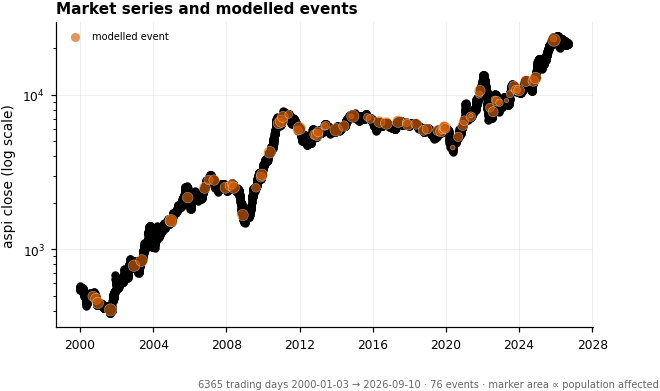

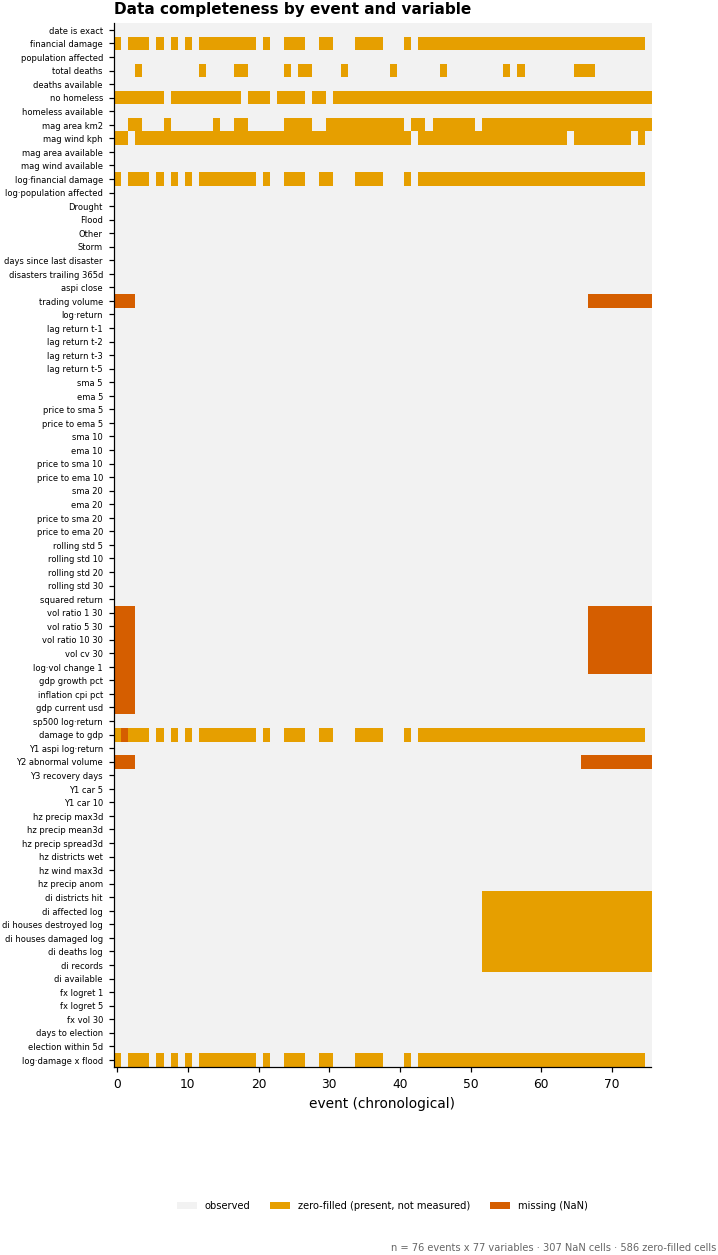

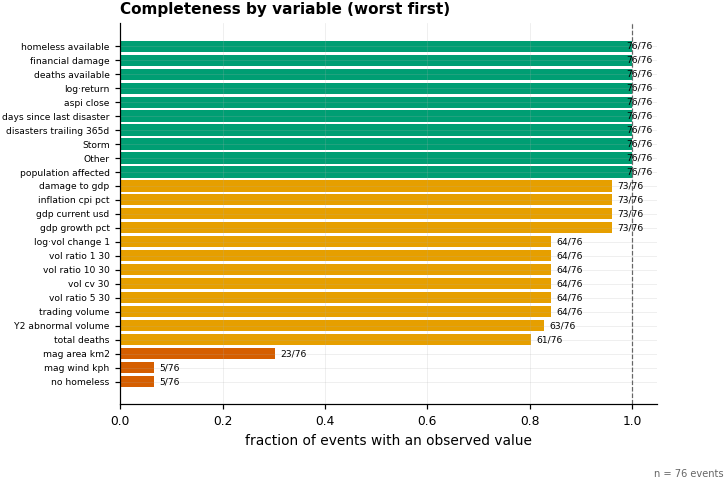

In [2]:
from src.evaluation import eda_figures as eda

# 1. Acquisition -- what the market series covers and where the events fall inside it.
market = load_frame("market")
eda.plot_event_timeline(market, dataset)

# 2. Completeness -- the three-state map, then the same thing ranked.
_, completeness_state = eda.plot_missingness_matrix(dataset)
_, completeness = eda.plot_missingness_ranked(dataset)

print("Least complete variables:")
print((completeness.head(8) * 100).round(1).to_string())
print()
_zero = int((completeness_state == 1.0).sum().sum())
_nan = int((completeness_state == 2.0).sum().sum())
print(f"cells that are present but NOT measured (zero-filled): {_zero}")
print(f"cells that are outright missing (NaN):                 {_nan}")
print()
if "damage_source" in dataset.columns:
    print("Damage provenance -- the study's key covariate:")
    print(dataset["damage_source"].value_counts().to_string())
    print(f"  events with a REAL damage figure: "
          f"{int((dataset['financial_damage'] > 0).sum())}/{len(dataset)}")

## 3.3 Outliers

Flagged two ways and **retained, never trimmed**. The IQR fence is conventional; the
modified z-score (median absolute deviation) is reported beside it because IQR fences are
themselves computed from quantiles that a few extreme events can move, and this sample has
exactly that shape.

The extreme events are named on the figure rather than merely counted. An outlier that
turns out to be the 2004 Indian Ocean tsunami is a real observation to be discussed in the
results, not a data error to be removed.

saved -> docs\figures\eda_03_outliers.png (180 KB)
          variable  n  iqr_outliers  mad_outliers  iqr_lo  iqr_hi
Y1_aspi_log_return 76             6             5 -0.0200  0.0196
Y2_abnormal_volume 63             2             1 -1.5238  1.2034
  Y3_recovery_days 76            14             0 -9.0000 15.0000

Y1_aspi_log_return: 6 IQR outliers, 5 MAD outliers
    [datetime.date(2001, 9, 1), datetime.date(2004, 12, 26), datetime.date(2005, 11, 21), datetime.date(2011, 11, 24), datetime.date(2020, 5, 17), datetime.date(2023, 7, 4)]
Y2_abnormal_volume: 2 IQR outliers, 1 MAD outliers
    [datetime.date(2011, 1, 5), datetime.date(2022, 12, 6)]
Y3_recovery_days: 14 IQR outliers, 0 MAD outliers
    [datetime.date(2000, 11, 18), datetime.date(2005, 11, 21), datetime.date(2007, 5, 2), datetime.date(2008, 4, 27), datetime.date(2008, 11, 22), datetime.date(2015, 9, 15), datetime.date(2017, 11, 3), datetime.date(2018, 5, 19), datetime.date(2022, 5, 29), datetime.date(2022, 10, 14), datetime.d

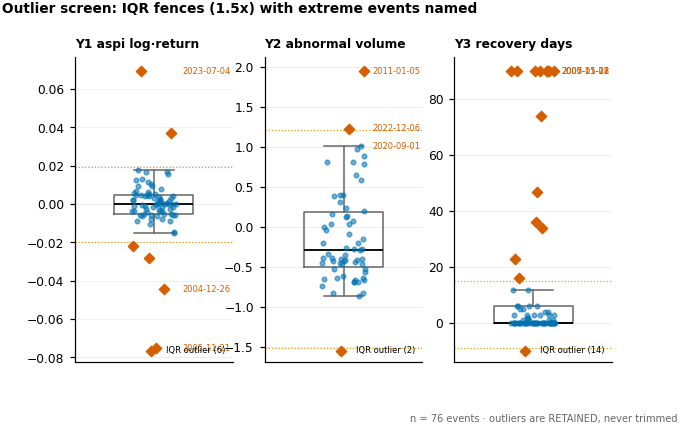

In [3]:
_, outliers = eda.plot_outlier_panel(dataset, TARGET_COLS[:3])
print(outliers.round(4).to_string(index=False))
print()
for _t in TARGET_COLS[:3]:
    _info = eda.outlier_table(dataset[_t])
    _ev = dataset.loc[_info["iqr_outliers"].index, "event_date"].dt.date.tolist()
    print(f"{_t}: {len(_ev)} IQR outliers, {len(_info['mad_outliers'])} MAD outliers")
    if _ev:
        print(f"    {_ev}")

## 3.4 Distributions and normality

Skew and excess kurtosis are annotated on every panel because two things downstream depend
on them: Ridge is a linear model, and the split is chronological. A heavily skewed
predictor whose tail sits entirely inside one fold is a specific, checkable risk rather
than a generic caveat.

The Q-Q panel tests the targets against a normal reference. A low Shapiro p does **not**
invalidate RMSE or R-squared, which make no distributional assumption -- but it does rule
out Gaussian confidence intervals, which is why every interval in this study is a
bootstrap.

saved -> docs\figures\eda_04_feature_distributions.png (134 KB)
Most skewed predictors:
               variable  n      mean    median   skew  excess_kurtosis
           mag_area_km2 23 24927.047 19891.000  2.208            5.659
       Y3_recovery_days 76    13.711     0.000  2.089            2.682
        hz_precip_max3d 76    70.794    63.565  1.941            4.881
   log_financial_damage 76     4.205     0.000  1.346           -0.043
     Y2_abnormal_volume 63    -0.109    -0.297  1.175            1.151
log_population_affected 76    11.296    11.663 -0.604           -0.252
        di_affected_log 76     7.905    10.755 -0.598           -1.438
          hz_wind_max3d 76     9.613     9.460  0.550            0.173



saved -> docs\figures\eda_05_qq_targets.png (182 KB)
            target  n  shapiro_p  normal_at_5pct
Y1_aspi_log_return 76     0.0000           False
Y2_abnormal_volume 63     0.0001           False
  Y3_recovery_days 76     0.0000           False
          Y1_car_5 76     0.0183           False
         Y1_car_10 76     0.0400           False


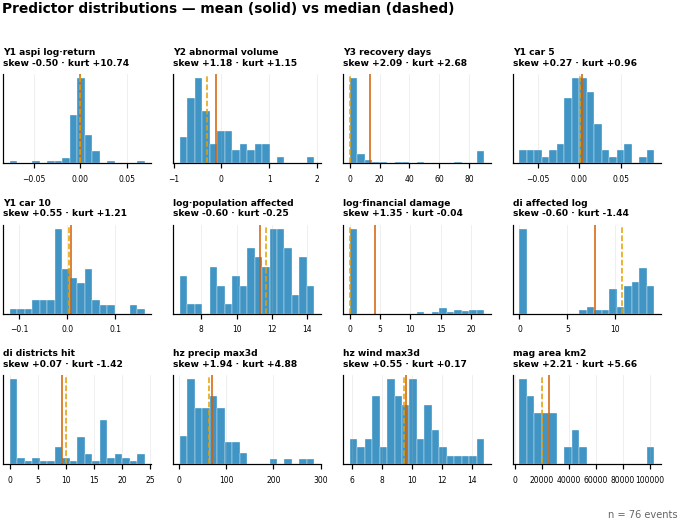

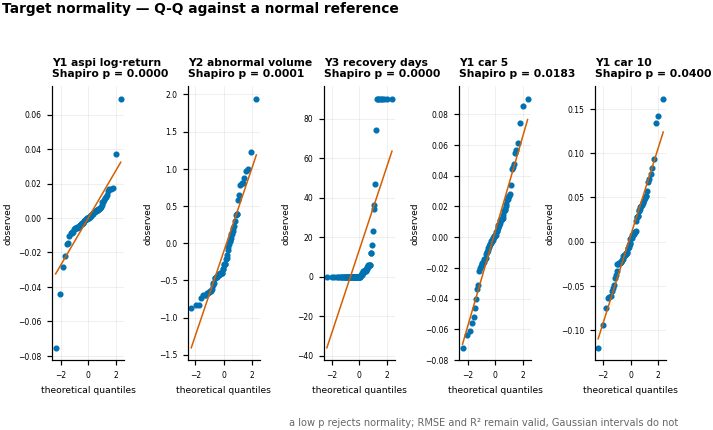

In [4]:
_SEVERITY = [c for c in ("log_population_affected", "log_financial_damage",
                         "di_affected_log", "di_districts_hit", "hz_precip_max3d",
                         "hz_wind_max3d", "mag_area_km2") if c in dataset.columns]

_, shape_stats = eda.plot_feature_distributions(dataset, TARGET_COLS + _SEVERITY)
print("Most skewed predictors:")
print(shape_stats.reindex(shape_stats["skew"].abs().sort_values(ascending=False).index)
      .head(8)[["variable", "n", "mean", "median", "skew", "excess_kurtosis"]]
      .round(3).to_string(index=False))
print()
_, normality = eda.plot_qq_grid(dataset, TARGET_COLS)
print(normality.round(4).to_string(index=False))

## 3.5 Predictor-target relationships

Spearman rather than Pearson: the severity variables are heavily skewed and a relationship
could be monotone without being linear.

**A trend line is drawn only where the correlation clears the critical value at this
sample size.** A fitted line through noise is the most misleading mark that can appear on
a scatter plot, and at n~76 the critical value is roughly 0.23 -- large enough that most
of these panels should, correctly, carry no line at all.

saved -> docs\figures\eda_06_scatter_matrix.png (300 KB)
target-severity pairs whose |rho| clears the critical value: 6 of 12
            target                 feature  spearman_rho     p  n  critical_r  distinguishable
Y2_abnormal_volume         di_affected_log        -0.350 0.005 63       0.248             True
Y1_aspi_log_return         di_affected_log        -0.316 0.005 76       0.225             True
Y1_aspi_log_return log_population_affected        -0.313 0.006 76       0.225             True
Y2_abnormal_volume log_population_affected        -0.287 0.023 63       0.248             True
Y2_abnormal_volume        di_districts_hit        -0.271 0.032 63       0.248             True
Y1_aspi_log_return        di_districts_hit        -0.267 0.020 76       0.225             True
Y2_abnormal_volume    log_financial_damage        -0.197 0.121 63       0.248            False
  Y3_recovery_days        di_districts_hit         0.167 0.149 76       0.225            False
  Y3_recovery_days 

saved -> docs\figures\eda_07_corr_Y1_aspi_log_return.png (146 KB)
Y1_aspi_log_return: strongest predictor is mag_wind_kph (rho=+0.600)


saved -> docs\figures\eda_07_corr_Y2_abnormal_volume.png (149 KB)
Y2_abnormal_volume: strongest predictor is no_homeless (rho=+0.700)


saved -> docs\figures\eda_07_corr_Y3_recovery_days.png (149 KB)
Y3_recovery_days: strongest predictor is log_return (rho=-0.364)


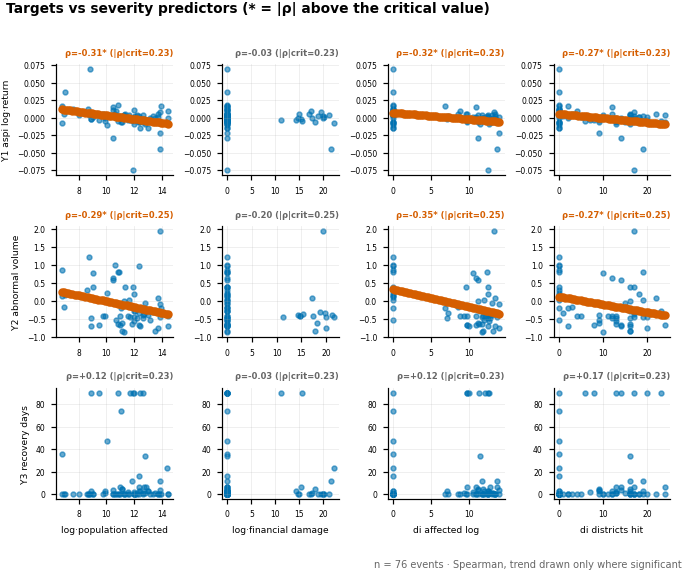

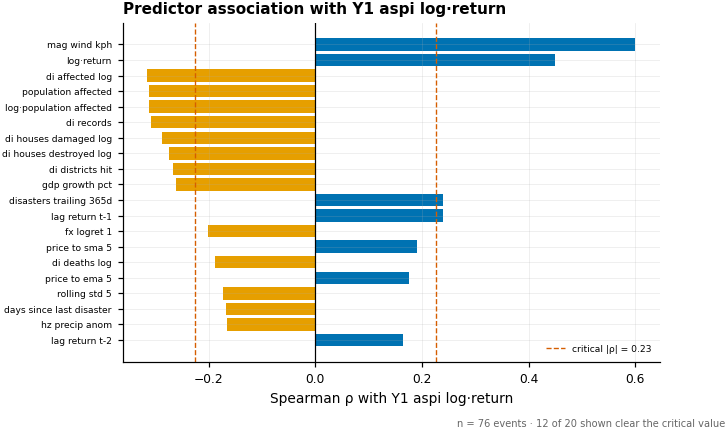

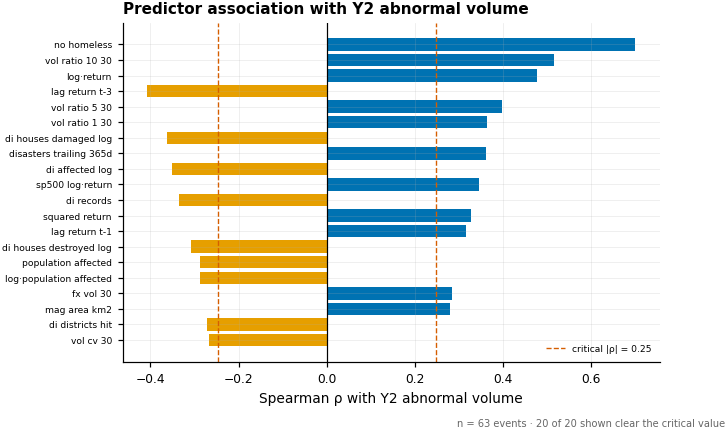

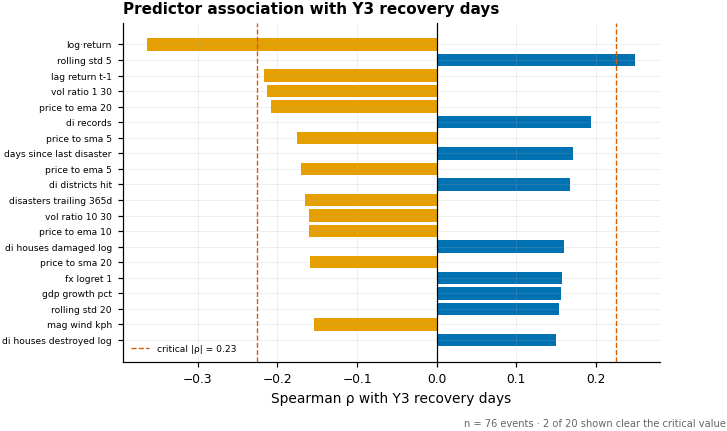

In [5]:
_, assoc = eda.plot_target_scatter_matrix(dataset, TARGET_COLS[:3], _SEVERITY[:4])
_sig = assoc[assoc.distinguishable]
print(f"target-severity pairs whose |rho| clears the critical value: "
      f"{len(_sig)} of {len(assoc)}")
print(assoc.sort_values("spearman_rho", key=abs, ascending=False)
      .head(10).round(3).to_string(index=False))
print()
for _t in TARGET_COLS[:3]:
    _, _bars = eda.plot_feature_target_correlation(dataset, _t, FEATURE_COLS)
    if _bars is not None and len(_bars):
        _top = _bars.iloc[0]
        print(f"{_t}: strongest predictor is {_top.feature} (rho={_top.rho:+.3f})")

## 3.6 Class balance and panel coverage

Prevalence is plotted per classification label **before any model is fitted**, because it
determines what an accuracy figure can possibly mean. A label at prevalence 0.90 hands the
always-predict-majority rule 0.90 accuracy for free, so a model scoring near that has
demonstrated nothing. This is why the reported criterion is balanced accuracy with an AUC
interval, not raw accuracy.

The sector coverage figure shows the panel is unbalanced: five of the twenty indices do
not span the study window.

saved -> docs\figures\eda_09_class_balance.png (140 KB)
             label  n  n_pos  prevalence
C1_negative_return 76     36       0.474
  C1b_adverse_move 76     25       0.329
   C2_volume_spike 63     22       0.349
 C3_recovers_in_90 76     68       0.895
 C3b_slow_recovery 76     36       0.474
  C4_car5_negative 76     35       0.461

Labels where raw accuracy is gameable by the majority rule:
  C1b_adverse_move: majority rule alone scores 0.671 accuracy
  C2_volume_spike: majority rule alone scores 0.651 accuracy
  C3_recovers_in_90: majority rule alone scores 0.895 accuracy


saved -> docs\figures\eda_10_sector_coverage.png (170 KB)

sector indices not spanning the window: 5 of 20
            sector        min        max  count
       Plantations 2000-01-03 2020-10-08   4950
    Power & Energy 2002-01-10 2023-06-28   5110
        Healthcare 2002-03-15 2023-06-28   5069
                IT 2002-05-20 2023-06-28   5029
Telecommunications 2003-01-14 2023-06-28   4870

EDA figures exported:
                          filename  kb
     eda_01_missingness_matrix.png 346
     eda_02_missingness_ranked.png 200
               eda_03_outliers.png 180
  eda_04_feature_distributions.png 134
             eda_05_qq_targets.png 182
         eda_06_scatter_matrix.png 300
eda_07_corr_Y1_aspi_log_return.png 146
eda_07_corr_Y2_abnormal_volume.png 149
  eda_07_corr_Y3_recovery_days.png 149
         eda_08_event_timeline.png 163
          eda_09_class_balance.png 140
        eda_10_sector_coverage.png 170


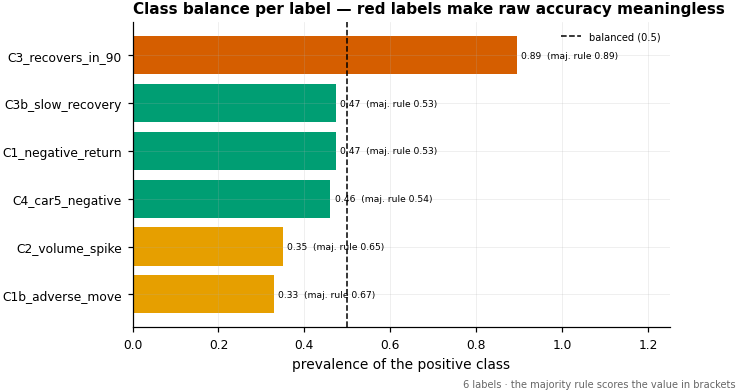

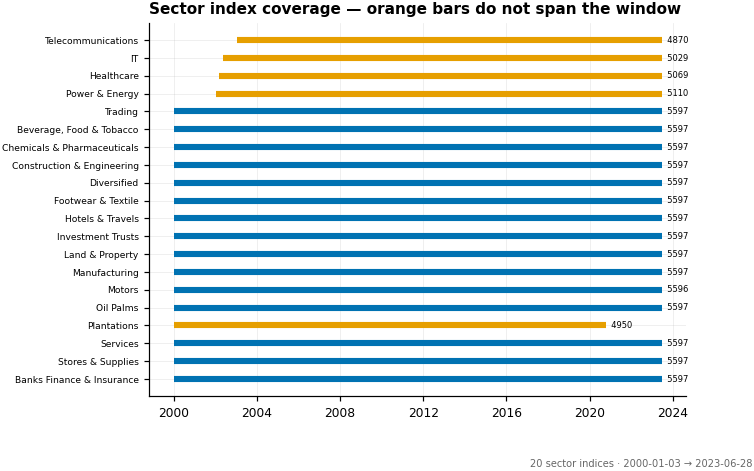

In [6]:
from src.models.classifiers import LABELS

_rows = []
for _name, _fn in LABELS.items():
    _lab = _fn(y, np.arange(len(y)), dataset)
    _rows.append({"label": _name, "n": int(_lab.notna().sum()),
                  "n_pos": int(_lab.sum()), "prevalence": float(_lab.mean())})
label_balance = pd.DataFrame(_rows)
eda.plot_class_balance(label_balance)
print(label_balance.round(3).to_string(index=False))
print()
print("Labels where raw accuracy is gameable by the majority rule:")
for _, _r in label_balance.iterrows():
    _maj = max(_r.prevalence, 1 - _r.prevalence)
    if _maj > 0.65:
        print(f"  {_r.label}: majority rule alone scores {_maj:.3f} accuracy")

try:
    from src.data_pipeline.cse_raw_loaders import load_sector_indices
    _sector_long = load_sector_indices(DATA_DIR / "07Market Indices - Daily.xls")
    _, _cov = eda.plot_sector_coverage(_sector_long)
    _short = _cov[(_cov["min"] > _cov["min"].min()) | (_cov["max"] < _cov["max"].max())]
    print()
    print(f"sector indices not spanning the window: {len(_short)} of {len(_cov)}")
    print(_short[["sector", "min", "max", "count"]].to_string(index=False))
except Exception as _e:
    print(f"sector coverage figure skipped: {type(_e).__name__}: {_e}")

print()
print("EDA figures exported:")
print(eda.eda_manifest(FIGURE_DIR).to_string(index=False))

## 3.7 Target distributions

The ECDF row matters more than the histogram row. A histogram of Y3 buries its structure
inside a bin, while the ECDF shows the point mass at 0 and the point mass at the 90-day cap
as two unmistakable vertical jumps. That shape — zero-inflated and right-censored — is why
a single continuous regressor is the wrong model for Y3, and why the training-mean
predictor currently beats every fitted model on it.

saved -> docs\figures\fig_02_target_distributions.png (167 KB)
Y1_aspi_log_return     n= 76  mean=-2.867e-06  median=+2.738e-05  sd=0.01574  min=-0.07534  max=+0.06927
Y2_abnormal_volume     n= 63  mean=-0.1092  median=-0.2973  sd=0.5851  min=-0.8699  max=+1.942
Y3_recovery_days       n= 76  mean=+13.71  median=+0  sd=28.76  min=+0  max=+90
Y1_car_5               n= 76  mean=+0.00342  median=+0.001098  sd=0.03104  min=-0.07203  max=+0.09009
Y1_car_10              n= 76  mean=+0.007132  median=+0.003491  sd=0.04953  min=-0.1198  max=+0.1615


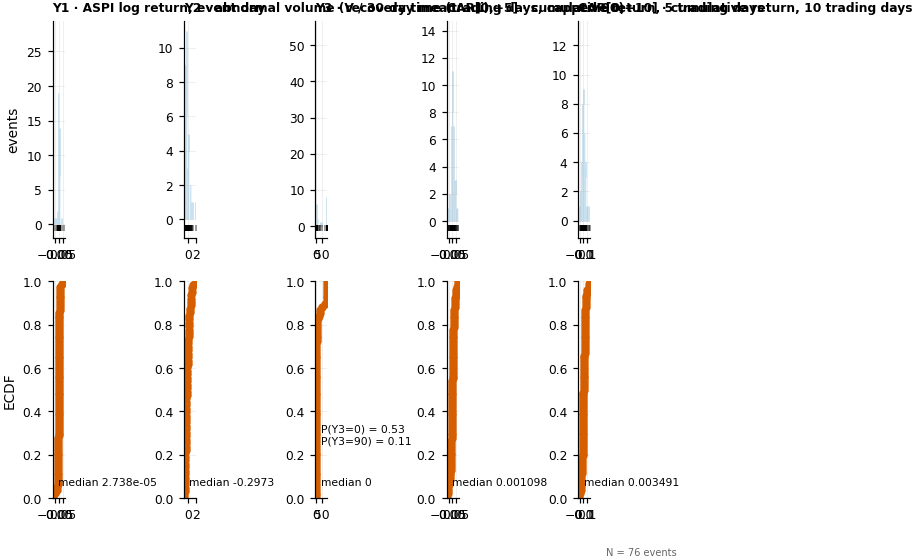

In [7]:
fig = fx.plot_target_distributions(dataset, TARGET_COLS)
fx.save_figure(fig, "fig_02_target_distributions")

for t in TARGET_COLS:
    v = pd.to_numeric(dataset[t], errors="coerce").dropna()
    print(f"{t:<22s} n={len(v):3d}  mean={v.mean():+.4g}  median={v.median():+.4g}  "
          f"sd={v.std():.4g}  min={v.min():+.4g}  max={v.max():+.4g}")


## 3.8 Y3 is not an independent target

The recovery window includes the event day and the baseline is the previous close, so any
event with a non-negative event-day return "recovers" on day 0 by construction. The
contingency panel shows the consequence: the cell for *Y1 ≥ 0 and Y3 > 0* is empty. Over
half of Y3 is a mechanical restatement of the sign of Y1, so Y3 performance cannot be read
as independent evidence, and a hurdle model's first stage is close to a sign classifier.

saved -> docs\figures\fig_03_target_dependence_y1_y3.png (123 KB)


WindowsPath('F:/CSE-disaster-impact-predictor/docs/figures/fig_03_target_dependence_y1_y3.png')

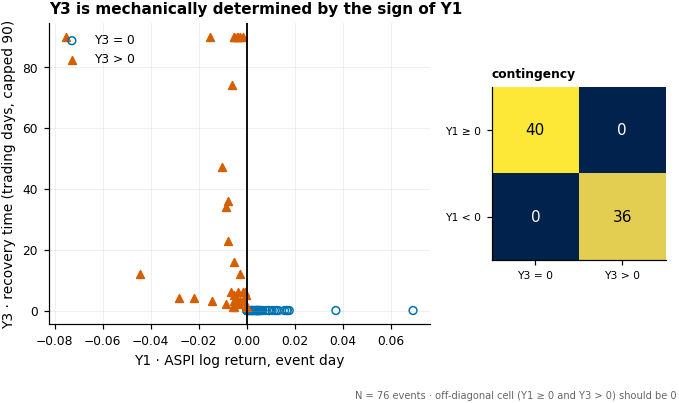

In [8]:
fig = fx.plot_target_dependence_y1_y3(dataset)
fx.save_figure(fig, "fig_03_target_dependence_y1_y3")


## 3.9 Feature correlation

Spearman rather than Pearson, for three reasons specific to this data. `financial_damage`
is zero for 47 of 64 events with a long tail on the remaining 17, so a Pearson coefficient
there is driven by two or three observations. Y3 has point masses at both ends, against
which only a rank measure is defensible. And because Spearman is invariant to monotone
transforms, a column and its own logarithm read exactly **1.00** — not a defect but the
cleanest possible statement that the two are one variable.

Cells below the significance threshold for this sample size are greyed out. With n = 64
that threshold is |ρ| ≈ 0.25; without the mask a reader will point at a 0.3 cell and ask
what it means, when the answer is "nothing".

saved -> docs\figures\fig_04_feature_correlation_heatmap.png (657 KB)


Most redundant feature pairs (Spearman):
              feature_a               feature_b       rho           group_a
       financial_damage    log_financial_damage  1.000000   damage/severity
    population_affected log_population_affected  1.000000   damage/severity
          date_is_exact        disaster_Drought -1.000000             other
            no_homeless      homeless_available  0.999260             other
           mag_wind_kph      mag_wind_available  0.999260             other
        price_to_sma_10         price_to_ema_10  0.980807  returns/momentum
           mag_area_km2      mag_area_available  0.978844             other
   log_financial_damage           damage_to_gdp  0.970176   damage/severity
       financial_damage           damage_to_gdp  0.970176   damage/severity
        price_to_sma_20         price_to_ema_20  0.962543  returns/momentum
         price_to_sma_5          price_to_ema_5  0.955024  returns/momentum
di_houses_destroyed_log   di_houses_damaged_log

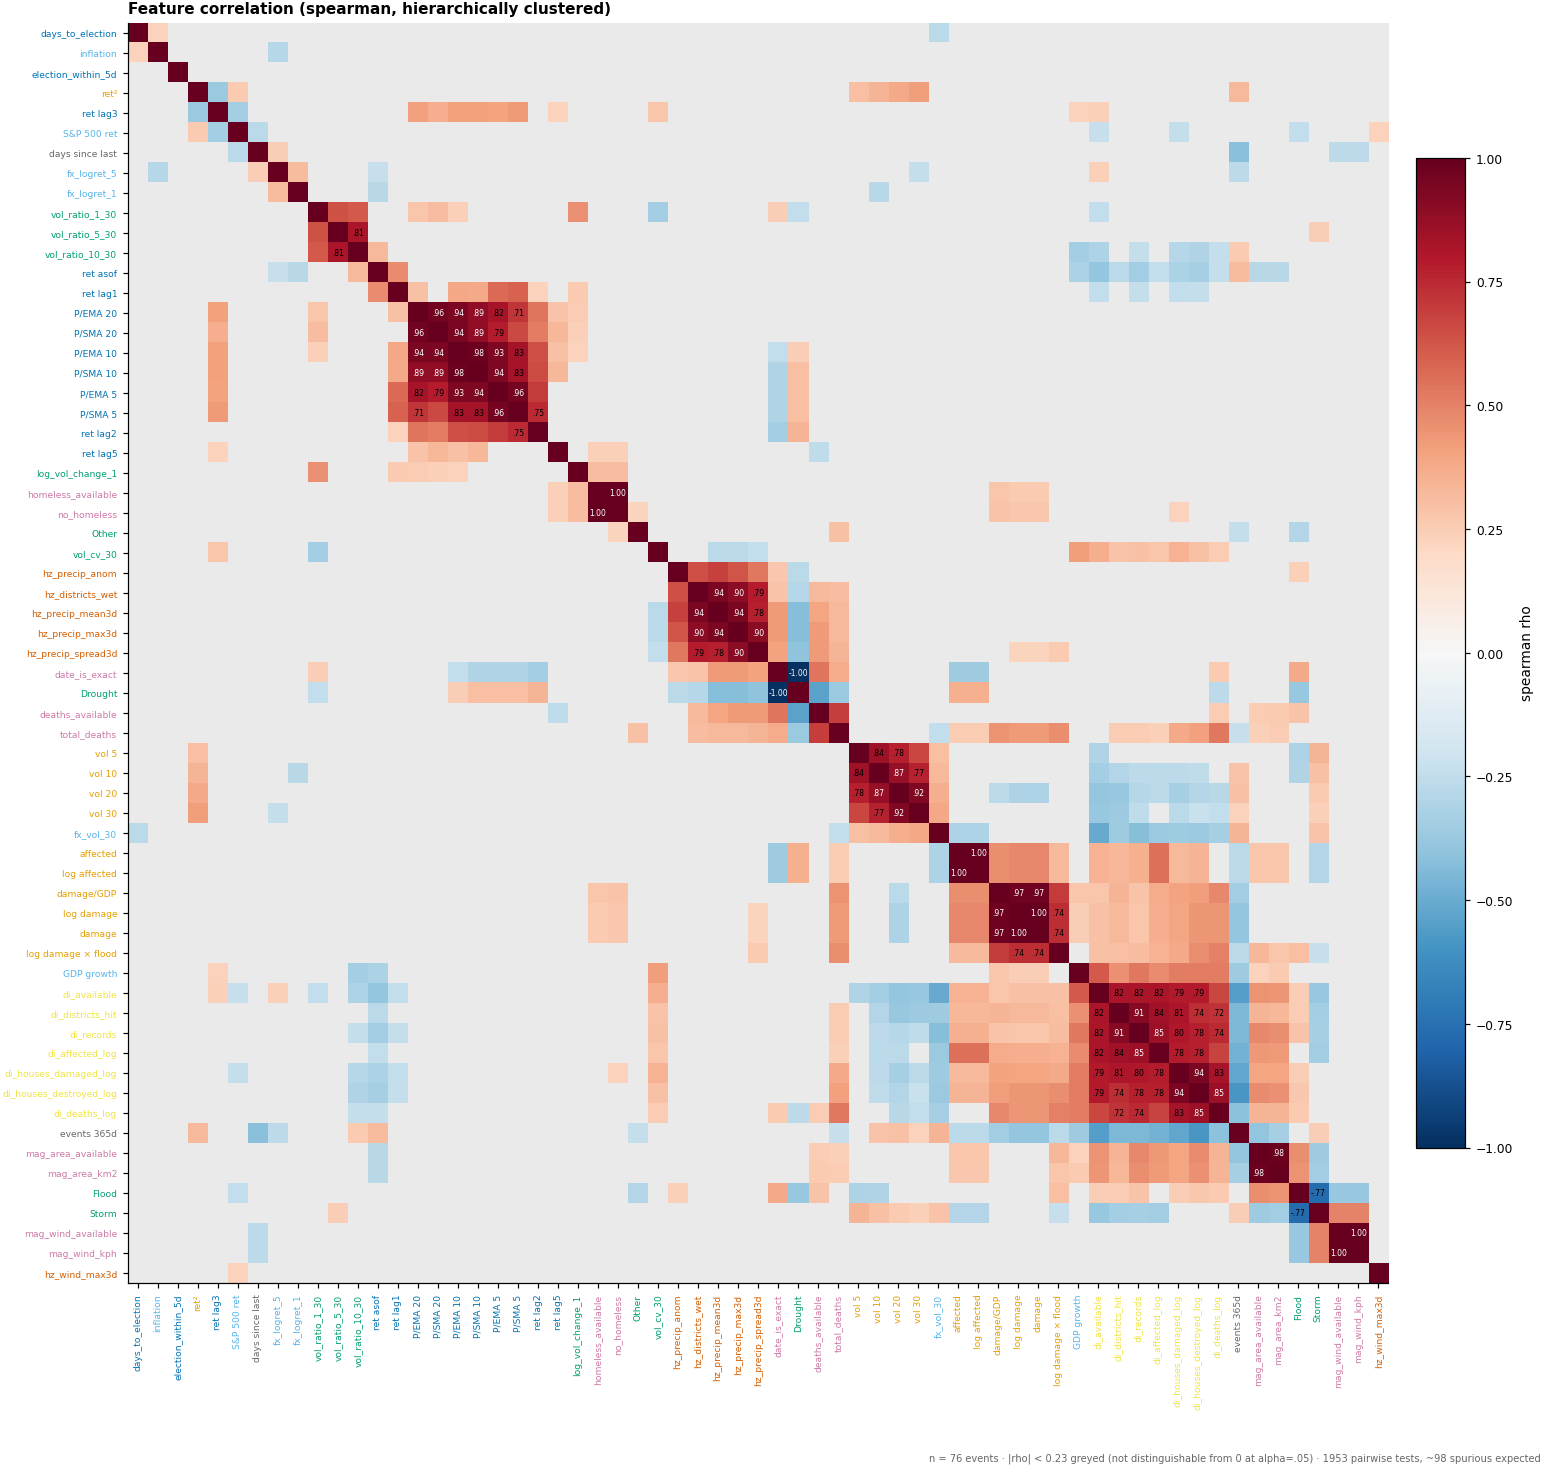

In [9]:
fig = fx.plot_feature_correlation_heatmap(X, method="spearman")
fx.save_figure(fig, "fig_04_feature_correlation_heatmap", formats=("png", "pdf"))

from src.evaluation import collinearity as col

pairs = col.top_correlated_pairs(X, top_n=12)
print("Most redundant feature pairs (Spearman):")
print(pairs[["feature_a", "feature_b", "rho", "group_a"]].to_string(index=False))


### 3.9.1 Variance inflation and condition indices

The same collinearity evidence from a second angle. A correlation heatmap shows
pairwise redundancy; VIF and the condition number catch redundancy spread across
three or more columns, which no pairwise view can see.

saved -> docs\figures\fig_06_collinearity_vif.png (334 KB)
condition number = 28981765019503632  (indices above 30 are the usual concern)


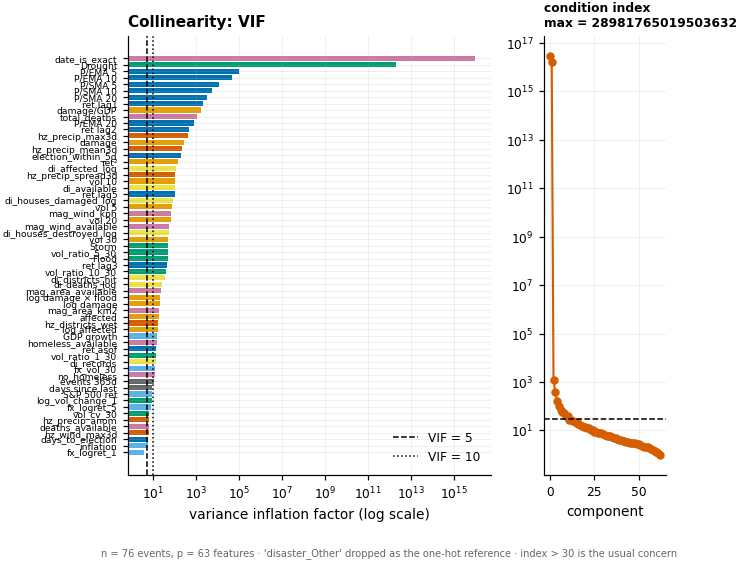

In [10]:
fig = fx.plot_vif(X)
fx.save_figure(fig, "fig_06_collinearity_vif")

ci = col.condition_indices(X)
print(f"condition number = {ci.max():.0f}  (indices above 30 are the usual concern)")


### 3.9.2 The pre-declared redundancy rule

Stated before any model was scored under it, so applying it cannot be selection on test
performance: **within any group of features whose pairwise |ρ| exceeds 0.95, keep the
single most primitive member — the one with the fewest derivation steps from a raw
measurement — and drop the rest.** Ties break alphabetically so the outcome is
deterministic.

The rule never consults a target, a fold or a score. Whatever it does to the metrics is
reported either way.

In [11]:
keep, drop, detail = col.redundant_drop_set(X, threshold=0.95)
print(f"Rule at |rho| >= 0.95: keep {len(keep)} features, drop {len(drop)}.\n")
if len(detail):
    print(detail.to_string(index=False))
else:
    print("No feature pair exceeds the threshold.")

save_json({"keep": keep, "drop": drop, "threshold": 0.95,
           "rule": "within a >=0.95 correlated group keep the least-derived member"},
          "collinearity_rule")


Rule at |rho| >= 0.95: keep 53 features, drop 10.

                dropped                kept  rho_with_kept            group
       disaster_Drought       date_is_exact       1.000000    disaster type
          damage_to_gdp    financial_damage       0.970176  damage/severity
   log_financial_damage    financial_damage       1.000000  damage/severity
log_population_affected population_affected       1.000000  damage/severity
            no_homeless  homeless_available       0.999260            other
           mag_area_km2  mag_area_available       0.978844            other
           mag_wind_kph  mag_wind_available       0.999260            other
         price_to_sma_5      price_to_ema_5       0.955024 returns/momentum
        price_to_sma_10     price_to_ema_10       0.980807 returns/momentum
        price_to_sma_20     price_to_ema_20       0.962543 returns/momentum
cached collinearity_rule.json


WindowsPath('F:/CSE-disaster-impact-predictor/disaster_finance_predictor/artifacts/collinearity_rule.json')

## 3.10 Walk-forward geometry

The two largest shocks in the sample — the 2004-12-26 tsunami and the 2005-11-21 flood —
are events 7 and 8, which places them permanently inside fold 0's *training* window. They
appear in no test fold. The held-out folds therefore carry markedly less variance than the
full sample, and since R² scores against the test set's own mean, that compression is part
of why pooled R² is negative. It also means the reported R² is **conservative**, not
flattering.

saved -> docs\figures\fig_09_walk_forward_folds.png (155 KB)
target                   full sigma   test sigma   ratio
Y1_aspi_log_return         0.015741     0.013805    0.88
Y2_abnormal_volume          0.58515      0.55099    0.94
Y3_recovery_days             28.755        29.56    1.03
Y1_car_5                    0.03104     0.034326    1.11
Y1_car_10                  0.049527     0.051412    1.04


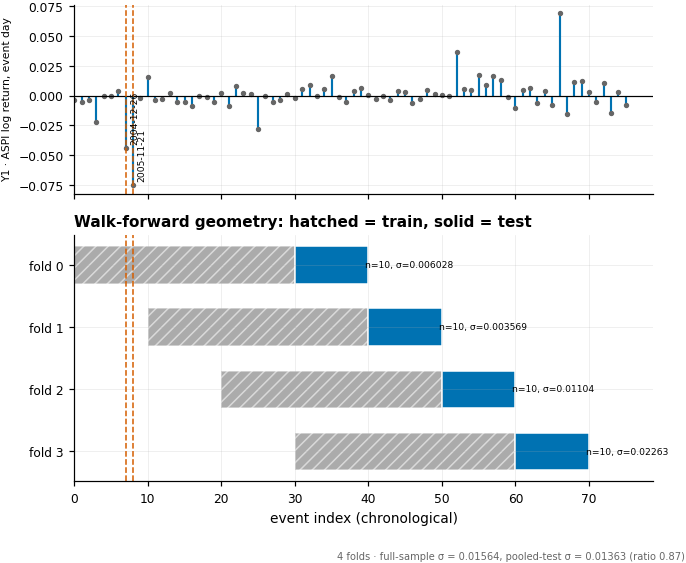

In [12]:
splits = load_object("splits")
fig = fx.plot_walk_forward_folds(splits, dataset, y)
fx.save_figure(fig, "fig_09_walk_forward_folds", formats=("png", "pdf"))

import numpy as np

test_idx = np.concatenate([np.asarray(s.test_index) for s in splits])
print(f"{'target':<22s} {'full sigma':>12s} {'test sigma':>12s} {'ratio':>7s}")
for t in TARGET_COLS:
    v = pd.to_numeric(y[t], errors="coerce")
    full, test = v.std(), v.iloc[test_idx].std()
    print(f"{t:<22s} {full:12.5g} {test:12.5g} {test / full:7.2f}")


## 3.11 What the damage features actually measure

Most Sri Lankan EM-DAT records carry no damage estimate, and the loader zero-fills them.
The damage block therefore behaves substantially as an indicator of **EM-DAT reporting
coverage** — itself correlated with severity and recency — rather than as a clean severity
measure. The interaction term `log_damage_x_flood` rests on an even narrower base.

In [13]:
if "damage_source" in dataset.columns:
    print(dataset["damage_source"].value_counts().to_string())
    has = int((dataset["financial_damage"] > 0).sum())
    print(f"\nevents with a real damage figure: {has}/{len(dataset)}")
    if "disaster_Flood" in dataset.columns:
        supp = int(((dataset["financial_damage"] > 0) & (dataset["disaster_Flood"] == 1)).sum())
        print(f"of which floods -- the entire support of log_damage_x_flood: {supp}")

print("\nExported figures:")
print(fx.figure_manifest().to_string(index=False))


damage_source
missing_zero_filled    58
emdat_cpi_adjusted     18

events with a real damage figure: 18/76
of which floods -- the entire support of log_damage_x_flood: 12

Exported figures:
                              filename  kb
       fig_02_target_distributions.png 167
    fig_03_target_dependence_y1_y3.png 123
fig_04_feature_correlation_heatmap.png 657
           fig_06_collinearity_vif.png 334
         fig_09_walk_forward_folds.png 155
         fig_11_conformal_coverage.png 111
                fig_14_roc_with_ci.png 193
    fig_17_model_vs_naive_baseline.png 122
 fig_18_skill_forest_vs_naive_zero.png  84
fig_18b_skill_forest_vs_train_mean.png  84
          fig_19_pred_vs_actual_y1.png 157
          fig_19_pred_vs_actual_y2.png 167
          fig_19_pred_vs_actual_y3.png 133
            fig_24_overfitting_gap.png 162
  fig_31_sector_response_and_skill.png 221
